In [1]:
!pip -q install datasets transformers evaluate accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00


In [2]:
import re
import time
import random
import numpy as np
import pandas as pd
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from sklearn.metrics import accuracy_score, classification_report, f1_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed
)
import evaluate
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# 1. Load dataset

In [4]:
dataset = load_dataset("emotion")
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [5]:
print(dataset["train"][0])
print(dataset["train"].features)

{'text': 'i didnt feel humiliated', 'label': 0}
{'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}


In [6]:
label_names = dataset["train"].features["label"].names
num_classes = len(label_names)

print("Label names:", label_names)
print("Number of classes:", num_classes)

Label names: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Number of classes: 6


In [7]:
train_texts = dataset["train"]["text"]
val_texts   = dataset["validation"]["text"]
test_texts  = dataset["test"]["text"]

train_labels = dataset["train"]["label"]
val_labels   = dataset["validation"]["label"]
test_labels  = dataset["test"]["label"]

print("Train size:", len(train_texts))
print("Validation size:", len(val_texts))
print("Test size:", len(test_texts))

Train size: 16000
Validation size: 2000
Test size: 2000


# 2. CNN approach
Clean text, build vocabulary, convert sentences to token id sequences, pad to same length, and use TextCNN for classification.

## 2.1 Preprocessing for CNN

In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    return text.split()

train_texts_cnn = [clean_text(t) for t in train_texts]
val_texts_cnn   = [clean_text(t) for t in val_texts]
test_texts_cnn  = [clean_text(t) for t in test_texts]

print(train_texts_cnn[0])

i didnt feel humiliated


## 2.2 Create vocabulary

In [9]:
counter = Counter()
for text in train_texts_cnn:
    counter.update(tokenize(text))

max_vocab_size = 20000
special_tokens = ["<PAD>", "<UNK>"]

most_common = counter.most_common(max_vocab_size - len(special_tokens))
vocab = {tok: idx for idx, tok in enumerate(special_tokens)}

for word, _ in most_common:
    vocab[word] = len(vocab)

print("Vocabulary size:", len(vocab))
print("Sample vocab items:", list(vocab.items())[:10])

Vocabulary size: 15214
Sample vocab items: [('<PAD>', 0), ('<UNK>', 1), ('i', 2), ('feel', 3), ('and', 4), ('to', 5), ('the', 6), ('a', 7), ('feeling', 8), ('that', 9)]


## 2.3 Encode and Padding

In [10]:
def encode_text(text, vocab):
    return [vocab.get(tok, vocab["<UNK>"]) for tok in tokenize(text)]

train_encoded = [encode_text(t, vocab) for t in train_texts_cnn]
val_encoded   = [encode_text(t, vocab) for t in val_texts_cnn]
test_encoded  = [encode_text(t, vocab) for t in test_texts_cnn]

lengths = [len(x) for x in train_encoded]
max_len = min(50, max(lengths))

print("Max sequence length for CNN:", max_len)
print("Min length:", min(lengths))
print("Mean length:", round(sum(lengths) / len(lengths), 2))

Max sequence length for CNN: 50
Min length: 2
Mean length: 19.17


In [11]:
def pad_sequence(seq, max_len, pad_value=0):
    if len(seq) < max_len:
        seq = seq + [pad_value] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq

train_padded = [pad_sequence(x, max_len) for x in train_encoded]
val_padded   = [pad_sequence(x, max_len) for x in val_encoded]
test_padded  = [pad_sequence(x, max_len) for x in test_encoded]

## 2.4 Dataset và DataLoader

In [12]:
class EmotionCNNDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = torch.tensor(texts, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

train_ds_cnn = EmotionCNNDataset(train_padded, train_labels)
val_ds_cnn   = EmotionCNNDataset(val_padded, val_labels)
test_ds_cnn  = EmotionCNNDataset(test_padded, test_labels)

train_loader_cnn = DataLoader(train_ds_cnn, batch_size=64, shuffle=True)
val_loader_cnn   = DataLoader(val_ds_cnn, batch_size=64)
test_loader_cnn  = DataLoader(test_ds_cnn, batch_size=64)

## 2.5 Build Model TextCNN

In [13]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, filter_sizes=[3,4,5], num_filters=100, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)

        conv_outs = []
        for conv in self.convs:
            c = F.relu(conv(x))
            p = F.max_pool1d(c, kernel_size=c.shape[2]).squeeze(2)
            conv_outs.append(p)

        out = torch.cat(conv_outs, dim=1)
        out = self.dropout(out)
        out = self.fc(out)
        return out

## 2.6 Training and Evaluation for CNN

In [14]:
def train_one_epoch_cnn(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

@torch.no_grad()
def evaluate_cnn(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    return total_loss / len(loader), acc, f1, all_labels, all_preds

In [15]:
cnn_model = TextCNN(
    vocab_size=len(vocab),
    embed_dim=128,
    num_classes=num_classes,
    filter_sizes=[3,4,5],
    num_filters=100,
    dropout=0.5
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)

num_epochs_cnn = 8
best_val_acc_cnn = 0
cnn_history = []

start_time_cnn = time.time()

for epoch in range(num_epochs_cnn):
    train_loss = train_one_epoch_cnn(cnn_model, train_loader_cnn, optimizer, criterion, device)
    val_loss, val_acc, val_f1, _, _ = evaluate_cnn(cnn_model, val_loader_cnn, criterion, device)

    cnn_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "val_f1_macro": val_f1
    })

    print(f"Epoch {epoch+1}/{num_epochs_cnn}")
    print(f"  Train loss: {train_loss:.4f}")
    print(f"  Val loss:   {val_loss:.4f}")
    print(f"  Val acc:    {val_acc:.4f}")
    print(f"  Val f1:     {val_f1:.4f}")

    if val_acc > best_val_acc_cnn:
        best_val_acc_cnn = val_acc
        torch.save(cnn_model.state_dict(), "best_textcnn.pt")

cnn_train_time = time.time() - start_time_cnn
print(f"\nCNN training time: {cnn_train_time:.2f} seconds")

Epoch 1/8
  Train loss: 1.5752
  Val loss:   1.3305
  Val acc:    0.5195
  Val f1:     0.2990
Epoch 2/8
  Train loss: 1.1235
  Val loss:   0.7766
  Val acc:    0.7215
  Val f1:     0.6163
Epoch 3/8
  Train loss: 0.6055
  Val loss:   0.4348
  Val acc:    0.8600
  Val f1:     0.8239
Epoch 4/8
  Train loss: 0.3506
  Val loss:   0.3339
  Val acc:    0.8805
  Val f1:     0.8541
Epoch 5/8
  Train loss: 0.2331
  Val loss:   0.2940
  Val acc:    0.8910
  Val f1:     0.8581
Epoch 6/8
  Train loss: 0.1684
  Val loss:   0.2817
  Val acc:    0.9020
  Val f1:     0.8733
Epoch 7/8
  Train loss: 0.1389
  Val loss:   0.2687
  Val acc:    0.9045
  Val f1:     0.8752
Epoch 8/8
  Train loss: 0.1095
  Val loss:   0.2843
  Val acc:    0.9065
  Val f1:     0.8782

CNN training time: 15.85 seconds


In [16]:
cnn_history_df = pd.DataFrame(cnn_history)
cnn_history_df

,epoch,train_loss,val_loss,val_accuracy,val_f1_macro
0,1,1.575167,1.330469,0.5195,0.298967
1,2,1.123548,0.776627,0.7215,0.616306
2,3,0.605533,0.434819,0.8600,0.823922
3,4,0.350594,0.333855,0.8805,0.854065
4,5,0.233147,0.294029,0.8910,0.858106
5,6,0.168357,0.281740,0.9020,0.873285
6,7,0.138919,0.268727,0.9045,0.875239
7,8,0.109508,0.284273,0.9065,0.878184


## 2.7 Validation and Test for CNN

In [17]:
cnn_model.load_state_dict(torch.load("best_textcnn.pt", map_location=device))

cnn_test_loss, cnn_test_acc, cnn_test_f1, cnn_y_true, cnn_y_pred = evaluate_cnn(
    cnn_model, test_loader_cnn, criterion, device
)

print("CNN Test loss:", round(cnn_test_loss, 4))
print("CNN Test accuracy:", round(cnn_test_acc, 4))
print("CNN Test macro F1:", round(cnn_test_f1, 4))

CNN Test loss: 0.2778
CNN Test accuracy: 0.8995
CNN Test macro F1: 0.8513


In [18]:
print(classification_report(cnn_y_true, cnn_y_pred, target_names=label_names))

              precision    recall  f1-score   support

     sadness       0.95      0.93      0.94       581
         joy       0.93      0.93      0.93       695
        love       0.71      0.87      0.78       159
       anger       0.90      0.89      0.90       275
        fear       0.87      0.86      0.87       224
    surprise       0.78      0.64      0.70        66

    accuracy                           0.90      2000
   macro avg       0.86      0.85      0.85      2000
weighted avg       0.90      0.90      0.90      2000



## 2.8 Testing CNN with new sentences

In [19]:
def predict_text_cnn(text, model, vocab, max_len, label_names, device):
    model.eval()
    text = clean_text(text)
    encoded = encode_text(text, vocab)
    padded = pad_sequence(encoded, max_len)

    x = torch.tensor([padded], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(x)
        pred = torch.argmax(logits, dim=1).item()

    return label_names[pred]

samples = [
    "I am feeling great and excited today",
    "I am really scared about tomorrow",
    "I miss my friends and feel lonely"
]

for s in samples:
    print(s, "->", predict_text_cnn(s, cnn_model, vocab, max_len, label_names, device))

I am feeling great and excited today -> joy
I am really scared about tomorrow -> fear
I miss my friends and feel lonely -> sadness


# 3. RNN approach (BiLSTM)

This section builds a **full RNN pipeline** for text classification using a **BiLSTM** model.

The pipeline is kept separate from the CNN section:
1. Clean text for the RNN branch
2. Build RNN vocabulary
3. Encode and pad sequences
4. Create RNN `Dataset` and `DataLoader`
5. Train and evaluate a **BiLSTM** baseline
6. Test the model on new sentences

## 3.1 Preprocessing for RNN

We apply the same cleaning logic as before, but create a **separate set of variables** for the RNN pipeline so the section is self-contained.

In [20]:
def build_vocab(texts, min_freq=2, max_vocab_size=20000):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))

    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, freq in counter.most_common():
        if freq < min_freq:
            continue
        if len(vocab) >= max_vocab_size:
            break
        vocab[word] = len(vocab)

    return vocab

#preprocessing pipeline for the RNN branch
train_texts_rnn = [clean_text(text) for text in train_texts]
val_texts_rnn = [clean_text(text) for text in val_texts]
test_texts_rnn = [clean_text(text) for text in test_texts]

rnn_vocab = build_vocab(train_texts_rnn, min_freq=2)
rnn_max_len = max(len(text.split()) for text in train_texts_rnn)

X_train_rnn = [pad_sequence(encode_text(text, rnn_vocab), rnn_max_len) for text in train_texts_rnn]
X_val_rnn = [pad_sequence(encode_text(text, rnn_vocab), rnn_max_len) for text in val_texts_rnn]
X_test_rnn = [pad_sequence(encode_text(text, rnn_vocab), rnn_max_len) for text in test_texts_rnn]

print("RNN vocab size:", len(rnn_vocab))
print("RNN max_len:", rnn_max_len)
print("Sample encoded sequence length:", len(X_train_rnn[0]))


RNN vocab size: 7401
RNN max_len: 66
Sample encoded sequence length: 66


## 3.2 Dataset and DataLoader for RNN

Create dedicated `Dataset` and `DataLoader` objects for the BiLSTM model.

In [21]:
class TextDatasetRNN(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = torch.tensor(self.sequences[idx], dtype=torch.long)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return seq, label

train_dataset_rnn = TextDatasetRNN(X_train_rnn, train_labels)
val_dataset_rnn = TextDatasetRNN(X_val_rnn, val_labels)
test_dataset_rnn = TextDatasetRNN(X_test_rnn, test_labels)

train_loader_rnn = DataLoader(train_dataset_rnn, batch_size=64, shuffle=True)
val_loader_rnn = DataLoader(val_dataset_rnn, batch_size=64)
test_loader_rnn = DataLoader(test_dataset_rnn, batch_size=64)

print("RNN train batches:", len(train_loader_rnn))
print("RNN val batches:", len(val_loader_rnn))
print("RNN test batches:", len(test_loader_rnn))

RNN train batches: 250
RNN val batches: 32
RNN test batches: 32


## 3.3 Build BiLSTM model

In [22]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=1, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        x = self.embedding(x)                  # [B, T, E]
        _, (h_n, _) = self.lstm(x)            # h_n: [num_layers*2, B, H]
        h_fw = h_n[-2]                        # forward last layer
        h_bw = h_n[-1]                        # backward last layer
        h = torch.cat([h_fw, h_bw], dim=1)    # [B, 2H]
        h = self.dropout(h)
        return self.fc(h)


## 3.4 Train and validate BiLSTM

In [23]:
bilstm_model = BiLSTMClassifier(
    vocab_size=len(rnn_vocab),
    embed_dim=128,
    hidden_dim=128,
    num_classes=num_classes,
    num_layers=1,
    dropout=0.5
).to(device)

bilstm_criterion = nn.CrossEntropyLoss()
bilstm_optimizer = torch.optim.Adam(bilstm_model.parameters(), lr=1e-3)

num_epochs_bilstm = 8
best_val_acc_bilstm = 0
bilstm_history = []

start_time_bilstm = time.time()

for epoch in range(num_epochs_bilstm):
    train_loss = train_one_epoch_cnn(bilstm_model, train_loader_rnn, bilstm_optimizer, bilstm_criterion, device)
    val_loss, val_acc, val_f1, _, _ = evaluate_cnn(bilstm_model, val_loader_rnn, bilstm_criterion, device)

    bilstm_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "val_f1_macro": val_f1
    })

    print(f"Epoch {epoch+1}/{num_epochs_bilstm}")
    print(f"  Train loss: {train_loss:.4f}")
    print(f"  Val loss:   {val_loss:.4f}")
    print(f"  Val acc:    {val_acc:.4f}")
    print(f"  Val f1:     {val_f1:.4f}")

    if val_acc > best_val_acc_bilstm:
        best_val_acc_bilstm = val_acc
        torch.save(bilstm_model.state_dict(), "best_bilstm.pt")

bilstm_train_time = time.time() - start_time_bilstm
print(f"\nBiLSTM training time: {bilstm_train_time:.2f} seconds")

Epoch 1/8
  Train loss: 1.5239
  Val loss:   1.3237
  Val acc:    0.5120
  Val f1:     0.2282
Epoch 2/8
  Train loss: 1.0200
  Val loss:   0.7980
  Val acc:    0.7210
  Val f1:     0.5441
Epoch 3/8
  Train loss: 0.6028
  Val loss:   0.5455
  Val acc:    0.8125
  Val f1:     0.7409
Epoch 4/8
  Train loss: 0.3870
  Val loss:   0.4387
  Val acc:    0.8570
  Val f1:     0.8119
Epoch 5/8
  Train loss: 0.2792
  Val loss:   0.4148
  Val acc:    0.8650
  Val f1:     0.8220
Epoch 6/8
  Train loss: 0.2033
  Val loss:   0.3729
  Val acc:    0.8860
  Val f1:     0.8514
Epoch 7/8
  Train loss: 0.1533
  Val loss:   0.3627
  Val acc:    0.8905
  Val f1:     0.8566
Epoch 8/8
  Train loss: 0.1234
  Val loss:   0.3843
  Val acc:    0.8865
  Val f1:     0.8470

BiLSTM training time: 80.23 seconds


In [24]:
bilstm_history_df = pd.DataFrame(bilstm_history)
bilstm_history_df

,epoch,train_loss,val_loss,val_accuracy,val_f1_macro
0,1,1.523913,1.323738,0.5120,0.228172
1,2,1.020020,0.797981,0.7210,0.544076
2,3,0.602767,0.545511,0.8125,0.740899
3,4,0.386981,0.438696,0.8570,0.811915
4,5,0.279203,0.414792,0.8650,0.822021
5,6,0.203258,0.372863,0.8860,0.851396
6,7,0.153313,0.362714,0.8905,0.856647
7,8,0.123391,0.384254,0.8865,0.847038


## 3.5 Evaluate BiLSTM on the test set

In [25]:
bilstm_model.load_state_dict(torch.load("best_bilstm.pt", map_location=device))

bilstm_test_loss, bilstm_test_acc, bilstm_test_f1, bilstm_y_true, bilstm_y_pred = evaluate_cnn(
    bilstm_model, test_loader_rnn, bilstm_criterion, device
)

print("BiLSTM Test loss:", round(bilstm_test_loss, 4))
print("BiLSTM Test accuracy:", round(bilstm_test_acc, 4))
print("BiLSTM Test macro F1:", round(bilstm_test_f1, 4))
print(classification_report(bilstm_y_true, bilstm_y_pred, target_names=label_names))

BiLSTM Test loss: 0.356
BiLSTM Test accuracy: 0.881
BiLSTM Test macro F1: 0.8381
              precision    recall  f1-score   support

     sadness       0.91      0.92      0.92       581
         joy       0.94      0.89      0.92       695
        love       0.70      0.84      0.76       159
       anger       0.83      0.85      0.84       275
        fear       0.87      0.86      0.86       224
    surprise       0.73      0.73      0.73        66

    accuracy                           0.88      2000
   macro avg       0.83      0.85      0.84      2000
weighted avg       0.88      0.88      0.88      2000



## 3.6 Predict with BiLSTM on new sentences

In [26]:
def predict_text_bilstm(text, model, rnn_vocab, rnn_max_len, label_names, device):
    model.eval()
    text = clean_text(text)
    encoded = encode_text(text, vocab)
    padded = pad_sequence(encoded, max_len)

    x = torch.tensor([padded], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(x)
        pred = torch.argmax(logits, dim=1).item()

    return label_names[pred]

for s in samples:
    print(s, "->", predict_text_bilstm(s, bilstm_model, rnn_vocab, rnn_max_len, label_names, device))

I am feeling great and excited today -> joy
I am really scared about tomorrow -> fear
I miss my friends and feel lonely -> sadness


# 4. Transformer approach (DistilBERT)

Fine-tune DistilBERT for emotion classification.
- checkpoint: `distilbert-base-uncased`

## 4.1 Tokenizer và tokenize dataset

In [27]:
checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize_function(example):
    return tokenizer(example["text"], truncation=True)

tokenized_dataset = dataset.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
tokenized_dataset

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

## 4.2 Metric for Transformer

In [28]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")

    return {
        "accuracy": acc["accuracy"],
        "f1_macro": f1["f1"]
    }

## 4.3 DistilBERT transfer-learning strategies
Instead of using only one Transformer setting, we compare three strategies:

- **Freeze backbone**: freeze all DistilBERT encoder layers and train only the classification head.
- **Partial fine-tune**: unfreeze the last Transformer layer and the classification head.
- **Full fine-tune**: update all DistilBERT parameters.

The Transformer model used later in the notebook is the **best strategy selected by validation Macro-F1**.

In [29]:
import gc

id2label = {i: label_names[i] for i in range(num_classes)}
label2id = {label_names[i]: i for i in range(num_classes)}

TRANSFORMER_STRATEGIES = [
    ("freeze_backbone", "DistilBERT (Freeze Backbone)"),
    ("partial_finetune", "DistilBERT (Partial Fine-tune)"),
    ("full_finetune", "DistilBERT (Full Fine-tune)")
]

def build_distilbert_model(strategy_key):
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        num_labels=num_classes,
        id2label=id2label,
        label2id=label2id
    )

    if strategy_key == "freeze_backbone":
        for param in model.distilbert.parameters():
            param.requires_grad = False

    elif strategy_key == "partial_finetune":
        for param in model.distilbert.parameters():
            param.requires_grad = False

        for param in model.distilbert.transformer.layer[-1].parameters():
            param.requires_grad = True

    # Always train the classification head
    for param in model.pre_classifier.parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model

def count_parameters(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

## 4.4 Configuration for Training

In [30]:
def build_training_args(run_name):
    return TrainingArguments(
        output_dir=f"./emotion_distilbert_{run_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        report_to="none",
        save_total_limit=1
    )

## 4.5 Train Transformer

In [31]:
def probs_from_logits(logits):
    return torch.softmax(torch.tensor(logits), dim=1).numpy()

transformer_strategy_results = []
best_transformer_bundle = None
best_transformer_val_f1 = -1

for strategy_key, strategy_label in TRANSFORMER_STRATEGIES:
    print(f"\n===== Training {strategy_label} =====")
    set_seed(SEED)

    current_model = build_distilbert_model(strategy_key)
    trainable_params, total_params = count_parameters(current_model)

    current_trainer = Trainer(
        model=current_model,
        args=build_training_args(strategy_key),
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    start_time_transformer = time.time()
    current_trainer.train()
    current_train_time = time.time() - start_time_transformer

    val_output = current_trainer.predict(tokenized_dataset["validation"])
    val_preds = np.argmax(val_output.predictions, axis=-1)
    val_labels = val_output.label_ids
    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average="macro")

    test_output = current_trainer.predict(tokenized_dataset["test"])
    test_preds = np.argmax(test_output.predictions, axis=-1)
    test_labels = test_output.label_ids
    test_acc = accuracy_score(test_labels, test_preds)
    test_f1 = f1_score(test_labels, test_preds, average="macro")

    transformer_strategy_results.append({
        "Strategy Key": strategy_key,
        "Strategy": strategy_label,
        "Trainable Params": trainable_params,
        "Total Params": total_params,
        "Val Accuracy": val_acc,
        "Val Macro F1": val_f1,
        "Test Accuracy": test_acc,
        "Test Macro F1": test_f1,
        "Training Time (sec)": current_train_time
    })

    print(
        f"{strategy_label} | "
        f"Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f} | "
        f"Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f} | "
        f"Trainable Params: {trainable_params:,}"
    )

    if val_f1 > best_transformer_val_f1:
        best_transformer_val_f1 = val_f1
        best_transformer_bundle = {
            "strategy_key": strategy_key,
            "strategy_label": strategy_label,
            "model": current_trainer.model.cpu(),
            "train_time": current_train_time,
            "trainable_params": trainable_params,
            "total_params": total_params,
            "val_probs": probs_from_logits(val_output.predictions),
            "val_labels": val_labels,
            "val_preds": val_preds,
            "val_accuracy": val_acc,
            "val_f1_macro": val_f1,
            "test_logits": test_output.predictions,
            "test_probs": probs_from_logits(test_output.predictions),
            "test_labels": test_labels,
            "test_preds": test_preds,
            "test_accuracy": test_acc,
            "test_f1_macro": test_f1
        }

    del current_trainer, current_model, val_output, test_output
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

transformer_strategy_results_df = (
    pd.DataFrame(transformer_strategy_results)
    .sort_values(by=["Val Macro F1", "Val Accuracy"], ascending=False)
    .reset_index(drop=True)
)

best_transformer_strategy = best_transformer_bundle["strategy_key"]
best_transformer_strategy_label = best_transformer_bundle["strategy_label"]

transformer_model = best_transformer_bundle["model"].to(device)
transformer_train_time = best_transformer_bundle["train_time"]

transformer_y_true = best_transformer_bundle["test_labels"]
transformer_y_pred = best_transformer_bundle["test_preds"]

transformer_test_acc = best_transformer_bundle["test_accuracy"]
transformer_test_f1 = best_transformer_bundle["test_f1_macro"]

transformer_val_probs = best_transformer_bundle["val_probs"]
transformer_val_labels = best_transformer_bundle["val_labels"]
transformer_test_probs = best_transformer_bundle["test_probs"]
transformer_test_labels = best_transformer_bundle["test_labels"]

display(transformer_strategy_results_df)
print(f"Selected Transformer strategy for the rest of the notebook: {best_transformer_strategy_label}")


===== Training DistilBERT (Freeze Backbone) =====


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.532715,1.465007,0.491500,0.199186
2,1.434552,1.407079,0.502000,0.204764
3,1.400616,1.391847,0.501000,0.204374


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


DistilBERT (Full Fine-tune) | Val Acc: 0.9410, Val F1: 0.9177 | Test Acc: 0.9270, Test F1: 0.8796 | Trainable Params: 66,958,086


,Strategy Key,Strategy,Trainable Params,Total Params,Val Accuracy,Val Macro F1,Test Accuracy,Test Macro F1,Training Time (sec)
0,full_finetune,DistilBERT (Full Fine-tune),66958086,66958086,0.9410,0.917699,0.927,0.879590,269.808454
1,partial_finetune,DistilBERT (Partial Fine-tune),7683078,66958086,0.8445,0.812086,0.834,0.776400,111.485901
2,freeze_backbone,DistilBERT (Freeze Backbone),595206,66958086,0.5020,0.204764,0.495,0.200638,90.228217


Selected Transformer strategy for the rest of the notebook: DistilBERT (Full Fine-tune)


## 4.6 Evaluation on test set

In [32]:
transformer_test_results = {
    "selected_strategy": best_transformer_strategy_label,
    "test_accuracy": transformer_test_acc,
    "test_f1_macro": transformer_test_f1,
    "training_time_sec": transformer_train_time,
    "trainable_params": best_transformer_bundle["trainable_params"],
    "total_params": best_transformer_bundle["total_params"]
}

transformer_test_results

{'selected_strategy': 'DistilBERT (Full Fine-tune)',
 'test_accuracy': 0.927,
 'test_f1_macro': 0.8795896804988838,
 'training_time_sec': 269.8084535598755,
 'trainable_params': 66958086,
 'total_params': 66958086}

In [33]:
print("Selected Transformer strategy:", best_transformer_strategy_label)
print("Transformer Test accuracy:", round(transformer_test_acc, 4))
print("Transformer Test macro F1:", round(transformer_test_f1, 4))
print("Transformer training time (sec):", round(transformer_train_time, 2))

Selected Transformer strategy: DistilBERT (Full Fine-tune)
Transformer Test accuracy: 0.927
Transformer Test macro F1: 0.8796
Transformer training time (sec): 269.81


In [34]:
print(classification_report(transformer_y_true, transformer_y_pred, target_names=label_names))

              precision    recall  f1-score   support

     sadness       0.96      0.97      0.96       581
         joy       0.95      0.95      0.95       695
        love       0.82      0.84      0.83       159
       anger       0.96      0.90      0.93       275
        fear       0.86      0.93      0.89       224
    surprise       0.81      0.64      0.71        66

    accuracy                           0.93      2000
   macro avg       0.89      0.87      0.88      2000
weighted avg       0.93      0.93      0.93      2000



## 4.7 Validation for Transformer with new sentences

In [36]:
def predict_text_transformer(text, model, tokenizer, device):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        pred_id = torch.argmax(outputs.logits, dim=1).item()

    return model.config.id2label[pred_id]

samples = [
    "I am feeling great and excited today",
    "I am really scared about tomorrow",
    "I miss my friends and feel lonely"
]

for s in samples:
    print(s, "->", predict_text_transformer(s, transformer_model, tokenizer, device))

I am feeling great and excited today -> joy
I am really scared about tomorrow -> fear
I miss my friends and feel lonely -> sadness


# 5. CNN vs Transformer

In [37]:
comparison_df = pd.DataFrame([
    {
        "Model": "CNN",
        "Test Accuracy": cnn_test_acc,
        "Test Macro F1": cnn_test_f1,
        "Training Time (sec)": cnn_train_time
    },
    {
        "Model": "DistilBERT",
        "Test Accuracy": transformer_test_acc,
        "Test Macro F1": transformer_test_f1,
        "Training Time (sec)": transformer_train_time
    }
])

comparison_df

,Model,Test Accuracy,Test Macro F1,Training Time (sec)
0,CNN,0.8995,0.851283,15.849884
1,DistilBERT,0.9270,0.879590,269.808454


In [38]:
winner_acc = comparison_df.loc[comparison_df["Test Accuracy"].idxmax(), "Model"]
winner_f1 = comparison_df.loc[comparison_df["Test Macro F1"].idxmax(), "Model"]
faster_model = comparison_df.loc[comparison_df["Training Time (sec)"].idxmin(), "Model"]

print("Best model by Accuracy:", winner_acc)
print("Best model by Macro F1:", winner_f1)
print("Faster model:", faster_model)

Best model by Accuracy: DistilBERT
Best model by Macro F1: DistilBERT
Faster model: CNN


# 6. Error analysis

In [39]:
@torch.no_grad()
def get_model_probabilities(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []

    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)

        all_probs.append(probs.cpu())
        all_labels.append(y)

    all_probs = torch.cat(all_probs, dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()
    return all_probs, all_labels

def plot_confusion(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
    ax.set_title(title)
    plt.show()

def get_misclassified_examples(texts, y_true, y_pred, label_names, n=10):
    rows = []
    for text, true_label, pred_label in zip(texts, y_true, y_pred):
        if true_label != pred_label:
            rows.append({
                "text": text,
                "true_label": label_names[true_label],
                "pred_label": label_names[pred_label]
            })
    return pd.DataFrame(rows[:n])


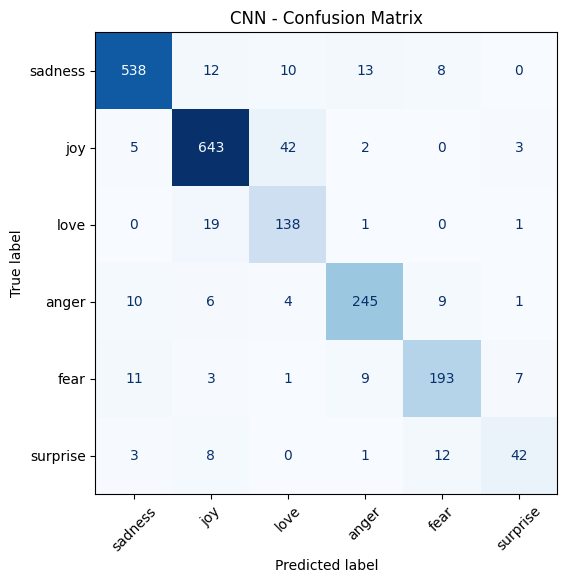

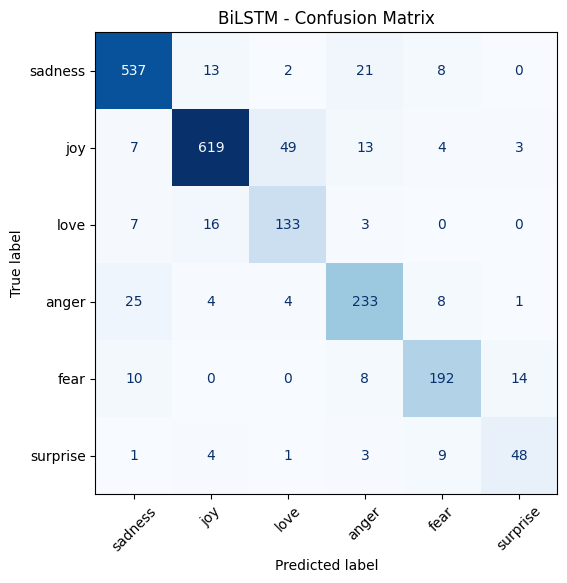

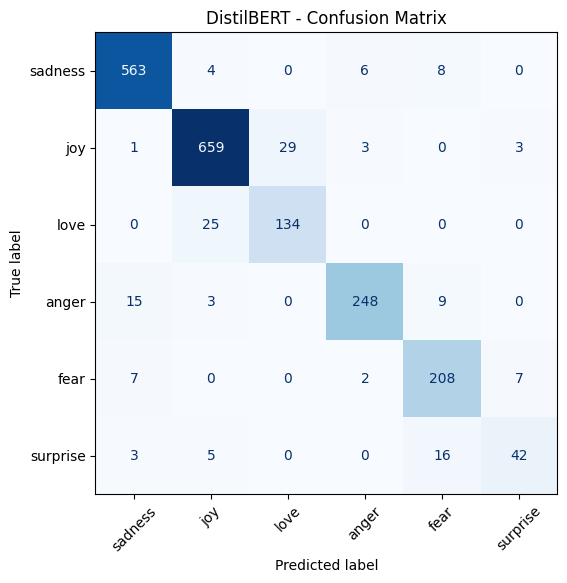

In [40]:
# Confusion matrices
plot_confusion(cnn_y_true, cnn_y_pred, label_names, "CNN - Confusion Matrix")
plot_confusion(bilstm_y_true, bilstm_y_pred, label_names, "BiLSTM - Confusion Matrix")
plot_confusion(transformer_y_true, transformer_y_pred, label_names, "DistilBERT - Confusion Matrix")


In [41]:
# Misclassified examples
print("CNN misclassified examples")
display(get_misclassified_examples(test_texts, cnn_y_true, cnn_y_pred, label_names, n=10))

print("BiLSTM misclassified examples")
display(get_misclassified_examples(test_texts, bilstm_y_true, bilstm_y_pred, label_names, n=10))

print("DistilBERT misclassified examples")
display(get_misclassified_examples(test_texts, transformer_y_true, transformer_y_pred, label_names, n=10))


CNN misclassified examples


,text,true_label,pred_label
0,i felt anger when at the end of a telephone call,anger,love
1,i don t feel particularly agitated,fear,anger
2,i pay attention it deepens into a feeling of b...,fear,sadness
3,im not sure the feeling of loss will ever go a...,sadness,love
4,i also tell you in hopes that anyone who is st...,sadness,joy
5,i had been talking to coach claudia barcomb an...,joy,love
6,i feel a little stunned but can t imagine what...,surprise,anger
7,i feel a bit stressed even though all the thin...,anger,sadness
8,i feel like i am in paradise kissing those swe...,joy,sadness
9,i feel my heart is tortured by what i have done,anger,fear


BiLSTM misclassified examples


,text,true_label,pred_label
0,i explain why i clung to a relationship with a...,joy,love
1,i pay attention it deepens into a feeling of b...,fear,anger
2,i feel just bcoz a fight we get mad to each ot...,anger,fear
3,im not sure the feeling of loss will ever go a...,sadness,joy
4,i feel a bit stressed even though all the thin...,anger,sadness
5,i think they have always been proponents of th...,joy,love
6,i am right handed however i play billiards lef...,surprise,fear
7,i feel like i am in paradise kissing those swe...,joy,love
8,im feeling angry at someone i do something tho...,anger,love
9,i feel needy but comfortable with it i feel vu...,sadness,fear


DistilBERT misclassified examples


,text,true_label,pred_label
0,i don t feel particularly agitated,fear,anger
1,i feel if i completely hated things i d exerci...,anger,sadness
2,i feel a bit stressed even though all the thin...,anger,sadness
3,i am right handed however i play billiards lef...,surprise,fear
4,i feel like i am in paradise kissing those swe...,joy,love
5,i was feeling weird the other day and it went ...,fear,surprise
6,when a friend dropped a frog down my neck,anger,fear
7,i feel my heart is tortured by what i have done,anger,fear
8,im feeling generous today heres one more you m...,love,joy
9,i actually feel agitated which led to a terrib...,anger,fear


## 7. Model comparison



In [44]:
comparison_df = pd.DataFrame([
    {
        "Model": "CNN",
        "Test Accuracy": cnn_test_acc,
        "Test Macro F1": cnn_test_f1,
        "Training Time (sec)": cnn_train_time
    },
    {
        "Model": "BiLSTM",
        "Test Accuracy": bilstm_test_acc,
        "Test Macro F1": bilstm_test_f1,
        "Training Time (sec)": bilstm_train_time
    },
    {
        "Model": "DistilBERT",
        "Test Accuracy": transformer_test_acc,
        "Test Macro F1": transformer_test_f1,
        "Training Time (sec)": transformer_train_time
    }
]).sort_values(by=["Test Macro F1", "Test Accuracy"], ascending=False).reset_index(drop=True)

comparison_df

,Model,Test Accuracy,Test Macro F1,Training Time (sec)
0,DistilBERT,0.9270,0.879590,269.808454
1,CNN,0.8995,0.851283,15.849884
2,BiLSTM,0.8810,0.838095,80.226797


In [45]:
best_f1_model = comparison_df.loc[comparison_df["Test Macro F1"].idxmax(), "Model"]
best_acc_model = comparison_df.loc[comparison_df["Test Accuracy"].idxmax(), "Model"]

print(f"Best model by Macro F1: {best_f1_model}")
print(f"Best model by Accuracy: {best_acc_model}")

Best model by Macro F1: DistilBERT
Best model by Accuracy: DistilBERT


## 8 Conclusion

- **CNN** is the lightest baseline and trains quickly.
- **BiLSTM** adds a genuine RNN-based baseline for sequential modeling.
- **DistilBERT** is usually the strongest single model, but also the most expensive.
- **Ensemble (CNN + DistilBERT)** may further improve accuracy/F1 by combining local n-gram features from CNN with contextual representations from DistilBERT.
- The confusion matrices and misclassified examples help explain **where each model fails** and which emotion pairs are frequently confused.